# EE200 Course Project — Q2: The Midnight Episode 

**Nirajkumar Binod Prasad (240701)**  
**Rinku Raj (240866)**

The goal of the problem is to detect the point where ECG changes from normal rhythm to arrhythmic rhytm. For this we can use healthy hearbeat as a template and compare with others.Also we explore the frequency domain of ECG signal, spectrogram and sampling effects

ecg: (5000,), template: (200,), fs = 250 Hz


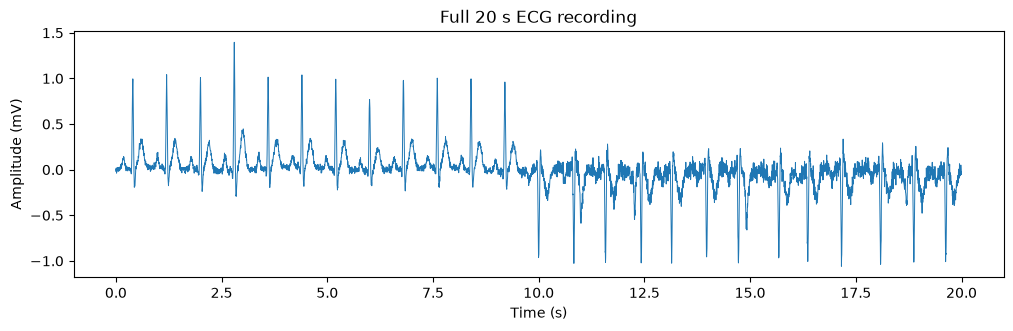

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, find_peaks, decimate
from pathlib import Path

DATA_DIR = Path("Q2_data")
fs = 250
ecg = np.load(DATA_DIR / "patient_ecg.npy")
tmpl = np.load(DATA_DIR / "template.npy")
N, L = len(ecg), len(tmpl)
t = np.arange(N) / fs
print(f"ecg: {ecg.shape}, template: {tmpl.shape}, fs = {fs} Hz")

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(t, ecg, lw=0.7)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (mV)")
ax.set_title("Full 20 s ECG recording")
plt.show()

We can see that this signal is regular in intial postion and then visible changes later. The goal of the following analysis is to identify this transition automatically using quantitative signal-processing methods.

## (a) Reading the signal

**(i) Clip duration.** $N = 5000$ samples at $f_s = 250$ Hz, so duration $= N/f_s$ .

(ii)  A healthy beat repeats every $T = 0.8$ s, so heart rate
$= 60/T$ bpm, and one beat occupies $f_s \cdot T$ samples.

**(iii) Fundamental frequency.** As the ECG is periodic with fundamental period T so 
fundamental frequency is simply $f_0 = 1/T$.

In [2]:
duration = N / fs
beat_period = 0.8
bpm = 60 / beat_period
samples_per_beat = fs * beat_period
f0 = 1 / beat_period

print(f"(i)   Clip duration       = {N}/{fs} = {duration} s")
print(f"(ii)  Heart rate          = 60/{beat_period} = {bpm} bpm")
print(f"      Samples per beat   = {fs}*{beat_period} = {samples_per_beat:.0f} samples")
print(f"(iii) Fundamental f0      = 1/{beat_period} = {f0} Hz")
print(f"      Template length     = {L} samples")

(i)   Clip duration       = 5000/250 = 20.0 s
(ii)  Heart rate          = 60/0.8 = 75.0 bpm
      Samples per beat   = 250*0.8 = 200 samples
(iii) Fundamental f0      = 1/0.8 = 1.25 Hz
      Template length     = 200 samples


So, the clip is **20 s** long. The healthy heart rate is **75 bpm**, with each beat
occupying **200 samples** and the fundamental frequency is $f_0 = $ **1.25 Hz**.

## (b) Healthy heart in frequency domain

**(i)** The healthy ECG is nearly periodic, so its magnitude spectrum is not a smooth continuous curve. Instead, it consists of discrete spectral lines at the fundamental frequency $f_0$ and its harmonics ie multiple of $f_0$.


**(ii)** The QRS complex is narrow and sharp, and the P and T waves are broader and smoother. As narrow time-domain features require a wider frequency range for representation, the QRS complex contributes most of the higher-frequency content of the ECG signal.

**(iii)** If the heart rate increases to 150 bpm provided it remains periodic, the new period becomes $T'=60/150=0.4$ s. Therefore, the fundamental frequency becomes $f_0'=1/T'=2.5$ Hz. Spectrum occur at multiple of $f_0$ so the space between the spectrum componoent also get doubled.

Frequency resolution df = fs/N = 0.1042 Hz
Strongest spectral lines (Hz) and which harmonic of f0=1.25Hz they are:
  f =  5.000 Hz   harmonic # = 4.00
  f =  1.250 Hz   harmonic # = 1.00
  f =  3.750 Hz   harmonic # = 3.00
  f =  8.750 Hz   harmonic # = 7.00
  f = 10.000 Hz   harmonic # = 8.00
  f =  6.250 Hz   harmonic # = 5.00
  f = 11.250 Hz   harmonic # = 9.00
  f =  7.500 Hz   harmonic # = 6.00


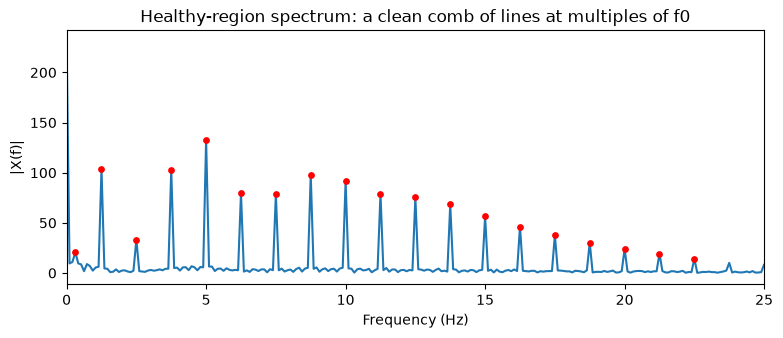

In [3]:
healthy_12 = ecg[:2400]
freqs = np.fft.rfftfreq(len(healthy_12), d=1/fs)
mag = np.abs(np.fft.rfft(healthy_12))
df = fs / len(healthy_12)

peaks, _ = find_peaks(mag, height=np.max(mag)*0.05)
order = np.argsort(-mag[peaks])[:8]
print(f"Frequency resolution df = fs/N = {df:.4f} Hz")
print("Strongest spectral lines (Hz) and which harmonic of f0=1.25Hz they are:")
for i in order:
    fpk = freqs[peaks[i]]
    print(f"  f = {fpk:6.3f} Hz   harmonic # = {fpk/1.25:.2f}")

fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(freqs, mag)
ax.scatter(freqs[peaks], mag[peaks], color='red', s=15, zorder=5)
ax.set_xlim(0, 25); ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("|X(f)|")
ax.set_title("Healthy-region spectrum: a clean comb of lines at multiples of f0")
plt.show()

The spectrum consists of distinct peaks at integer multiples of 1.25 Hz, which is consistent with the expected harmonic structure of a periodic signal.

QRS-only segment:  50% of energy by 7.5 Hz,  90% of energy by 15.0 Hz
P-wave-only segment: 50% of energy by 2.5 Hz,  90% of energy by 6.25 Hz


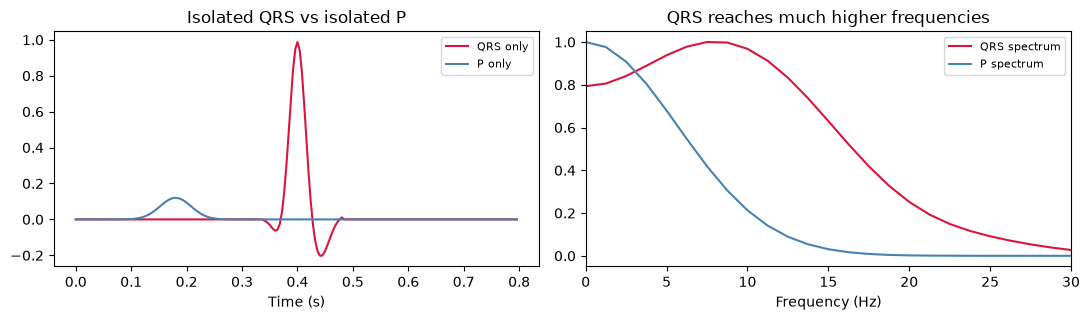

In [4]:
qrs_only = np.zeros_like(tmpl); qrs_only[85:121] = tmpl[85:121]
p_only   = np.zeros_like(tmpl); p_only[20:76]  = tmpl[20:76]

freqs_t = np.fft.rfftfreq(L, d=1/fs)
mag_qrs = np.abs(np.fft.rfft(qrs_only))
mag_p   = np.abs(np.fft.rfft(p_only))
cum_qrs = np.cumsum(mag_qrs**2) / np.sum(mag_qrs**2)
cum_p   = np.cumsum(mag_p**2)   / np.sum(mag_p**2)
f50_qrs, f90_qrs = freqs_t[np.searchsorted(cum_qrs, 0.50)], freqs_t[np.searchsorted(cum_qrs, 0.90)]
f50_p,   f90_p   = freqs_t[np.searchsorted(cum_p,   0.50)], freqs_t[np.searchsorted(cum_p,   0.90)]

print(f"QRS-only segment:  50% of energy by {f50_qrs} Hz,  90% of energy by {f90_qrs} Hz")
print(f"P-wave-only segment: 50% of energy by {f50_p} Hz,  90% of energy by {f90_p} Hz")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].plot(np.arange(L)/fs, qrs_only, color='crimson', label='QRS only')
ax[0].plot(np.arange(L)/fs, p_only, color='steelblue', label='P only')
ax[0].set_title("Isolated QRS vs isolated P"); ax[0].set_xlabel("Time (s)"); ax[0].legend(fontsize=8)
ax[1].plot(freqs_t, mag_qrs/mag_qrs.max(), color='crimson', label='QRS spectrum')
ax[1].plot(freqs_t, mag_p/mag_p.max(), color='steelblue', label='P spectrum')
ax[1].set_xlim(0, 30); ax[1].set_xlabel("Frequency (Hz)"); ax[1].set_title("QRS reaches much higher frequencies")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The QRS complex contains most of the high-frequency content of the ECG because it is sharp and changes rapidly. The P wave is smoother, so it mainly contains lower-frequency components.

If the heart rate increases to 150 bpm, the period becomes 0.4 s and the fundamental frequency becomes 2.5 Hz. Therefore, the spectral components move farther apart and the spacing between them doubles.


## (c) Cutting a heartbeat 

**(i)** To capture exactly one heartbeat, the window length should match the beat period. Since one beat occupies 200 samples, a suitable window is `ecg[0:200]`.

**(ii) & (iii)** Window lengths of 80, 200, and 600 samples are compared to see the effect of window size on the captured signal and its frequency-domain representation.

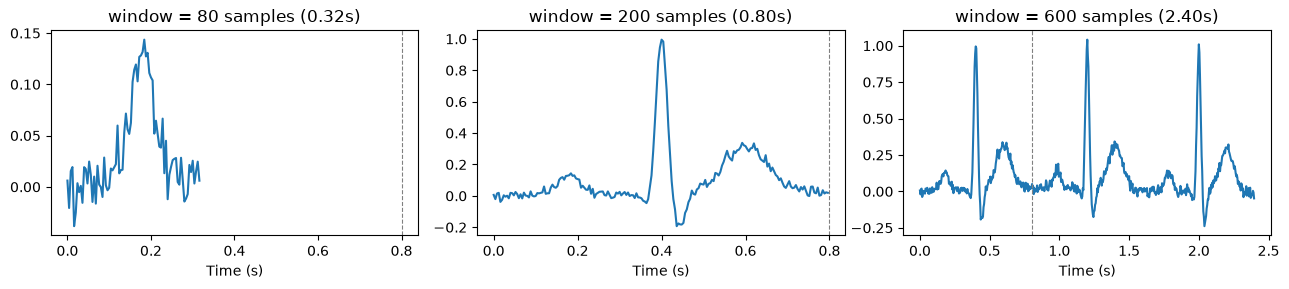

In [5]:
start = 0
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, w in zip(axes, [80, 200, 600]):
    seg = ecg[start:start+w]
    ax.plot(np.arange(len(seg))/fs, seg)
    ax.axvline(L/fs, color='gray', ls='--', lw=0.8)
    ax.set_title(f"window = {w} samples ({w/fs:.2f}s)"); ax.set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

**80 samples (0.32 s):** The window is too short and captures only part of the heartbeat. Important parts such as the QRS complex and T wave may be missed, so it cannot represent a complete beat.

**600 samples (2.4 s):** The window is too long and so it conatin more than one heartbeat. Therefore, it is not suitable for creating a single-beat template.

**Window length selection:** A window of **200 samples (0.8 s)** captures one complete heartbeat without including neighbouring beats, making it the best choice for the template.

## (d) Match the template 

$$
\rho(m) = \frac{\sum_k t[k]\,x[m+k]}{\lVert t \rVert\,\lVert x_m \rVert}
$$

**(i)** The normalized correlation is :

$$
-1 \leq \rho(m) \leq 1.
$$

A value of $\rho = 1$ indicates nearly perfect match

**(ii)** ECG signals may vary in amplitude.So by doing normalization, we can removes the effect of signal amplitude and thus we can make it complelty depend on waveform shape.

In [6]:
def rho(template, seg):
    denom = np.linalg.norm(template) * np.linalg.norm(seg)
    return float(np.dot(template, seg) / denom) if denom else 0.0

healthy_beat = ecg[0:L]
scaled_beat  = 2.0 * healthy_beat   
inverted_beat = ecg[2400:2600]      

print(f"rho(template, healthy beat)           = {rho(tmpl, healthy_beat):.4f}")
print(f"rho(template, 2× healthy beat)        = {rho(tmpl, scaled_beat):.4f}")
print(f"Raw dot product (healthy beat)        = {np.dot(tmpl, healthy_beat):.4f}")
print(f"Raw dot product (2× healthy beat)     = {np.dot(tmpl, scaled_beat):.4f}")
print(f"rho(template, inverted beat)          = {rho(tmpl, inverted_beat):.4f}")

rho(template, healthy beat)           = 0.9944
rho(template, 2× healthy beat)        = 0.9944
Raw dot product (healthy beat)        = 8.3438
Raw dot product (2× healthy beat)     = 16.6875
rho(template, inverted beat)          = -0.9879


Normalization makes the comparison depend on the shape of the heartbeat rather than its amplitude. Even if the heartbeat becomes taller, the normalized correlation changes very little.

**(iii)** An inverted beat gives a correlation close to **−1**. Since normal beats have correlation close to **1**, inverted beats can be detected easily.

## (e) Onset detection & the spectrogram

**(i)** Arrhythmia can be detected by computing the correlation for each beat and marking the onset when the correlation drops below a threshold.

A high threshold may tell false , while a low threshold may delay detection. Therefore, the threshold should be chosen carefully.

rho per beat: [ 0.994  0.992  0.994  0.997  0.992  0.99   0.994  0.99   0.994  0.992
  0.995  0.992 -0.988 -0.277 -0.561 -0.413 -0.096 -0.303 -0.141 -0.197
 -0.188 -0.142 -0.12  -0.146 -0.339]
First beat below threshold 0.5: beat #12, at t = 9.6 s


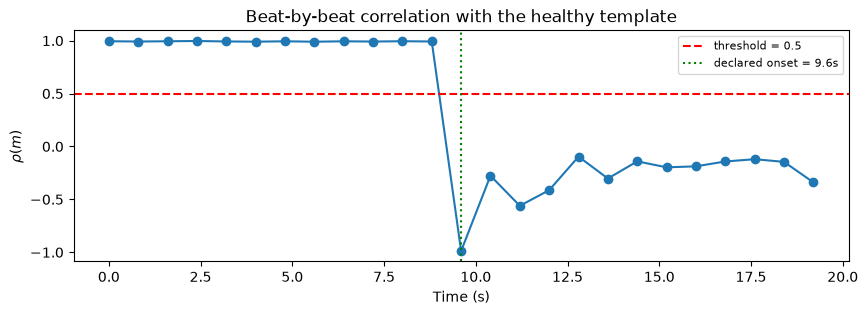

In [7]:
n_beats = N // L
rhos = np.array([rho(tmpl, ecg[i*L:(i+1)*L]) for i in range(n_beats)])
beat_times = np.arange(n_beats) * L / fs
THRESH = 0.5
onset_beat = np.where(rhos < THRESH)[0][0]
onset_time = onset_beat * L / fs

print("rho per beat:", np.round(rhos, 3))
print(f"First beat below threshold {THRESH}: beat #{onset_beat}, at t = {onset_time} s")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(beat_times, rhos, 'o-')
ax.axhline(THRESH, color='red', ls='--', label=f'threshold = {THRESH}')
ax.axvline(onset_time, color='green', ls=':', label=f'declared onset = {onset_time}s')
ax.set_xlabel("Time (s)"); ax.set_ylabel(r"$\rho(m)$")
ax.set_title("Beat-by-beat correlation with the healthy template")
ax.legend(fontsize=8); plt.show()

The correlation is close to **1** for beats which are at start, means they are similar to the healthy template. Then for later beataround 10s, the correlation drops sharply to about **−1**, means an abnormal beat.

Using a threshold of **0.5**, the arrhythmia is detected at around **10 s**, which matches the visible change in the ECG waveform.

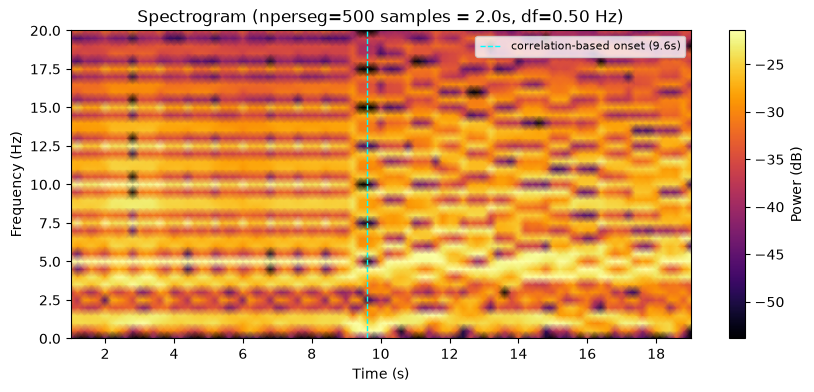

In [8]:
NPERSEG = 500   
f_sp, t_sp, Sxx = spectrogram(ecg, fs=fs, nperseg=NPERSEG, noverlap=NPERSEG-50)
Sxx_db = 10*np.log10(Sxx + 1e-12)
vmin, vmax = np.percentile(Sxx_db, 35), np.percentile(Sxx_db, 99.5)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(t_sp, f_sp, Sxx_db, shading='gouraud', cmap='inferno', vmin=vmin, vmax=vmax)
ax.set_ylim(0, 20)
ax.axvline(onset_time, color='cyan', ls='--', lw=1, label=f'correlation-based onset ({onset_time}s)')
ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Spectrogram (nperseg={NPERSEG} samples = {NPERSEG/fs:.1f}s, df={fs/NPERSEG:.2f} Hz)")
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(im, ax=ax, label='Power (dB)')
plt.show()

**(ii) Spectrogram analysis.** Before the arrhythmia starts, the spectrogram shows clear horizontal bands, indicating a regular heartbeat. After the onset, these bands become less clear and more irregular because the heartbeat is no longer repeating in a regular pattern.

**(iii) Comparison of methods.** The spectrogram and correlation plot may not show the exact same onset time. The correlation method checks each beat separately, so it can detect the first abnormal beat more accurately. The spectrogram uses a larger time window, so the change appears spread out over time.

For finding the exact onset of arrhythmia, the correlation method is more reliable. The spectrogram is mainly useful for visualizing how the ECG changes before and after the onset.

## (f) Sampling & aliasing 

**(i)** According to the Nyquist sampling theorem, a signal containing frequencies up to 40 Hz requires a sampling rate of at least

$$
f_s \ge 2 \times 40 = 80 \text{ Hz}.
$$

**(ii) & (iii)** At 50 Hz, the sharp QRS spikes are not recorded accurately and their shape becomes distorted. This can affect the performance of the detector since it relies on the shape of the heartbeat.

A low-pass filter can reduce this problem, but some useful ECG details are lost. The effect is shown below using a downsampled ECG signal.

A pure 35 Hz tone, sampled at 50 Hz with no filter, is indistinguishable from a 15 Hz tone -- that's aliasing.


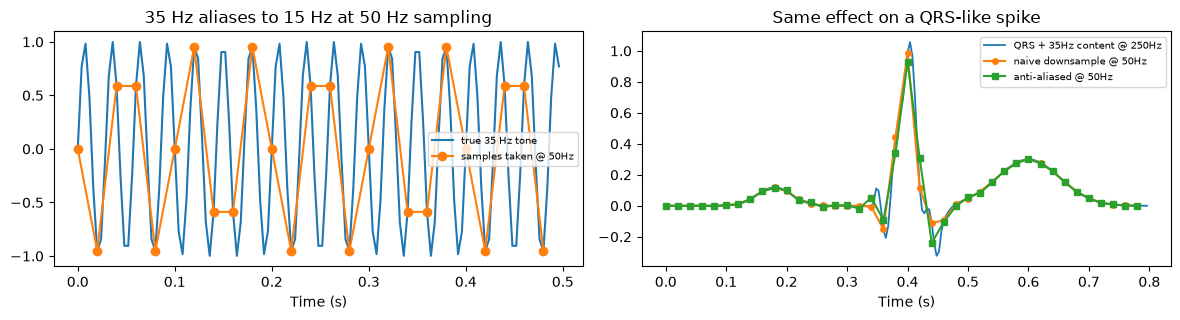

In [9]:
target_fs = 50
factor = fs // target_fs

dur = 0.5
tt_fine = np.arange(0, dur, 1/fs)
tone35 = np.sin(2*np.pi*35*tt_fine)
tt_coarse = np.arange(0, dur, 1/target_fs)
tone35_sampled = np.sin(2*np.pi*35*tt_coarse)
apparent_freq = abs(35 - round(35/target_fs)*target_fs)
print(f"A pure 35 Hz tone, sampled at {target_fs} Hz with no filter, is indistinguishable from "
      f"a {apparent_freq} Hz tone -- that's aliasing.")

t_tmpl = np.arange(L)/fs
qrs_region = tmpl.copy() + 0.15*np.sin(2*np.pi*35*t_tmpl)*(np.abs(t_tmpl-0.40) < 0.06)
naive = qrs_region[::factor]
proper = decimate(qrs_region, factor, ftype='iir')
t_naive = np.arange(len(naive))/target_fs
t_proper = np.arange(len(proper))/target_fs

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].plot(tt_fine, tone35, label='true 35 Hz tone')
ax[0].plot(tt_coarse, tone35_sampled, 'o-', label=f'samples taken @ {target_fs}Hz')
ax[0].set_title(f"35 Hz aliases to {apparent_freq} Hz at {target_fs} Hz sampling")
ax[0].set_xlabel("Time (s)"); ax[0].legend(fontsize=7.5)

ax[1].plot(t_tmpl, qrs_region, lw=1.3, label=f"QRS + 35Hz content @ {fs}Hz")
ax[1].plot(t_naive, naive, 'o-', ms=4, label=f"naive downsample @ {target_fs}Hz")
ax[1].plot(t_proper, proper, 's-', ms=4, label=f"anti-aliased @ {target_fs}Hz")
ax[1].set_title("Same effect on a QRS-like spike"); ax[1].set_xlabel("Time (s)")
ax[1].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

Aliasing can distort the QRS spike and make it look different from the original heartbeat. Since the detector relies on waveform shape, this can affect its accuracy.

**The fix:** apply a low-pass filter before sampling. The disadvantage is that some useful details of the ECG are lost and the QRS spikes become less sharp.


## (g) Prototyping the detector in code

The ECG is checked beat-by-beat and the correlation with the healthy template is calculated for each beat. The function returns the index of the first beat whose correlation is below the threshold. If this never happens, it returns \(-1\).

In [10]:
def find_onset(ecg_signal, template, threshold):
    L = len(template)
    n_beats = len(ecg_signal) // L
    t_norm = np.linalg.norm(template)

    for i in range(n_beats):
        m = i * L
        seg = ecg_signal[m:m + L]
        denom = t_norm * np.linalg.norm(seg)
        score = np.dot(template, seg) / denom if denom != 0 else 0.0
        if score < threshold:
            return m

    return -1


onset_sample = find_onset(ecg, tmpl, threshold=0.5)
print("find_onset(ecg, template, 0.5) ->", onset_sample,
      f"(= beat #{onset_sample // L}, t = {onset_sample / fs} s)" if onset_sample != -1 else "(no arrhythmia detected)")

find_onset(ecg, template, 0.5) -> 2400 (= beat #12, t = 9.6 s)


The function returns **m = 2400**, corresponding to **beat 12** at **t = 9.6 s**. 

## (h) Visualizing the spectrogram

The spectrogram was computed using `scipy.signal.spectrogram` and displayed using `matplotlib`. The main parameter is `nperseg`, which controls the size of the analysis window.

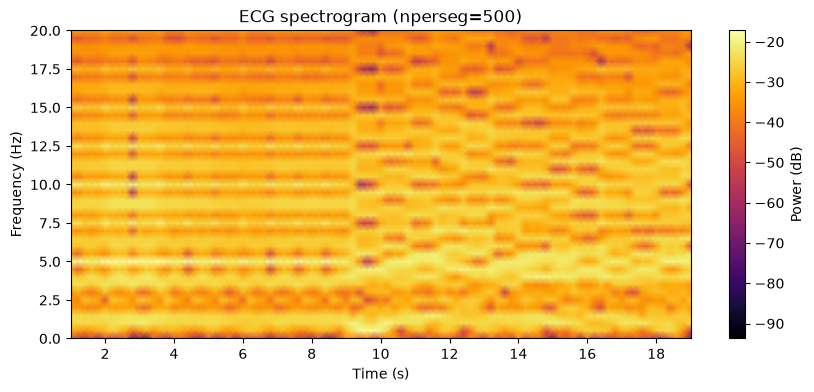

In [11]:
import matplotlib.pyplot as plt
from scipy import signal

nperseg = 500  

f, t_spec, Sxx = signal.spectrogram(ecg_signal := ecg, fs=fs, nperseg=nperseg, noverlap=nperseg - 50)
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='inferno')
plt.ylim(0, 20)
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title(f"ECG spectrogram (nperseg={nperseg})")
plt.colorbar(label="Power (dB)")
plt.show()

**Choice of window length.** I used **nperseg = 500** samples (2 s). A smaller window did not show the frequency pattern clearly, while a much larger window reduced the ability to see when the rhythm changed.

The corresponding frequency resolution is

$$
\Delta f = \frac{250}{500} = 0.5 \text{ Hz}.
$$

This value is sufficient for observing the important frequency components of the ECG.